Splitting dataset

In [3]:
# We need to take images in /images and /labels and split them into
# /images/train, /images/val, /labels/train, /labels/val

import os
import shutil
import random

# Define the paths 
images = './images'
labels = './labels'

# Create train/val split
split_ratio = 0.8

# Create train/val directories
os.makedirs(os.path.join(images, 'train'), exist_ok=True)
os.makedirs(os.path.join(images, 'val'), exist_ok=True)
os.makedirs(os.path.join(labels, 'train'), exist_ok=True)
os.makedirs(os.path.join(labels, 'val'), exist_ok=True)

# Get list of all image files
image_files = [f for f in os.listdir(images) if f.endswith(('.png'))]

# Shuffle the image files
random.shuffle(image_files)

# Calculate the number of images for training and validation
num_train = int(len(image_files) * split_ratio)
num_val = len(image_files) - num_train

# Split the image files into training and validation sets
train_images = image_files[:num_train]
val_images = image_files[num_train:]

# Split the label files into training and validation sets
train_labels = [f.replace('.png', '.txt') for f in train_images]
val_labels = [f.replace('.png', '.txt') for f in image_files[num_train:]]

# Copy the training images and labels
for img, lbl in zip(train_images, train_labels):
    shutil.copy(os.path.join(images, img), os.path.join(images, 'train', img))
    shutil.copy(os.path.join(labels, lbl), os.path.join(labels, 'train', lbl))

# Copy the validation images and labels
for img, lbl in zip(val_images, val_labels):
    shutil.copy(os.path.join(images, img), os.path.join(images, 'val', img))
    shutil.copy(os.path.join(labels, lbl), os.path.join(labels, 'val', lbl))

print(f"Training set size: {len(train_images)}")
print(f"Validation set size: {len(val_images)}")

Training set size: 84
Validation set size: 21


Actual fun stuff

In [4]:
from ultralytics import YOLO

model = YOLO('yolo26s.pt')

results = model.train(
    data='data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    project='runs/train',
    name='custom_yolo_aug',
    
    # --- Recommended Augmentation Hyperparameters ---
    hsv_h=0.0,         # Set to 0 if your scans are grayscale/false-color
    hsv_s=0.0,         # Set to 0 to avoid false color dependencies
    hsv_v=0.6,         # Crucial for varying detector exposures/intensity
    degrees=7.0,       # Small rotations for slight detector misalignments
    translate=0.2,     # Increased: Helps model learn off-center planes
    scale=0.6,         # Scale variations (zoom in/out)
    flipud=0.5,        # 50% chance of vertical flip
    fliplr=0.5,        # 50% chance of horizontal flip
    erasing=0.4        # Randomly blocks areas to simulate dead pixels or artifacts
)

Ultralytics 8.4.33 🚀 Python-3.12.3 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 4070, 12282MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=7.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.6, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=custom_yolo_aug2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspect

In [5]:
import shutil
# Load the custom trained model
best_model = YOLO('../runs/detect/runs/train/custom_yolo_aug2/weights/best.pt')

# Validate the model on the validation set to check mAP metrics
metrics = best_model.val()

# Export the model for deployment (e.g., ONNX format for wider compatibility)
path = best_model.export(format='onnx', dynamic=True)
print(path)
shutil.copy(path, './thomson-cutter.onnx')

Ultralytics 8.4.33 🚀 Python-3.12.3 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 4070, 12282MiB)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9894.6±1077.4 MB/s, size: 4210.9 KB)
val: Scanning /home/ash/oblisk/yolo-tune/labels/val.cache... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21 12.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.5it/s 1.3s3.6s
                   all         21         21      0.998          1      0.995      0.928
Speed: 6.1ms preprocess, 13.6ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /home/ash/oblisk/runs/detect/val2
Ultralytics 8.4.33 🚀 Python-3.12.3 torch-2.8.0+cu129 CPU (AMD Ryzen 5 7600X 6-Core Processor)

PyTorch: starting from '../runs/detect/runs/train/custom_yolo_aug2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 30

/home/ash/oblisk/venv/lib/python3.12/site-packages/torch/onnx/utils.py:1397: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.90...


/home/ash/oblisk/venv/lib/python3.12/site-packages/torch/onnx/symbolic_opset9.py:5350: UserWarning: Exporting aten::index operator of advanced indexing in opset 22 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(


ONNX: export success ✅ 2.1s, saved as '../runs/detect/runs/train/custom_yolo_aug2/weights/best.onnx' (36.9 MB)

Export complete (2.3s)
Results saved to /home/ash/oblisk/runs/detect/runs/train/custom_yolo_aug2/weights
Predict:         yolo predict task=detect model=../runs/detect/runs/train/custom_yolo_aug2/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=../runs/detect/runs/train/custom_yolo_aug2/weights/best.onnx imgsz=640 data=data.yaml  
Visualize:       https://netron.app
../runs/detect/runs/train/custom_yolo_aug2/weights/best.onnx


'./thomson-cutter.onnx'

In [6]:
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO('thomson-cutter.onnx', task='detect')

# Update the extension to .png or .jpeg if your dataset uses a different format
val_image_paths = glob.glob('test/*.png')

# Run batched inference with a confidence threshold of 0.5 (50%)
results = model.predict(source=val_image_paths, conf=0.5)

Loading thomson-cutter.onnx for ONNX Runtime inference...
WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.24.3 with CPUExecutionProvider

0: 640x640 1 main, 72.4ms
1: 640x640 1 main, 72.4ms
2: 640x640 1 main, 72.4ms
3: 640x640 1 main, 72.4ms
4: 640x640 1 main, 72.4ms
5: 640x640 1 main, 72.4ms
6: 640x640 1 main, 72.4ms
Speed: 2.4ms preprocess, 72.4ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)


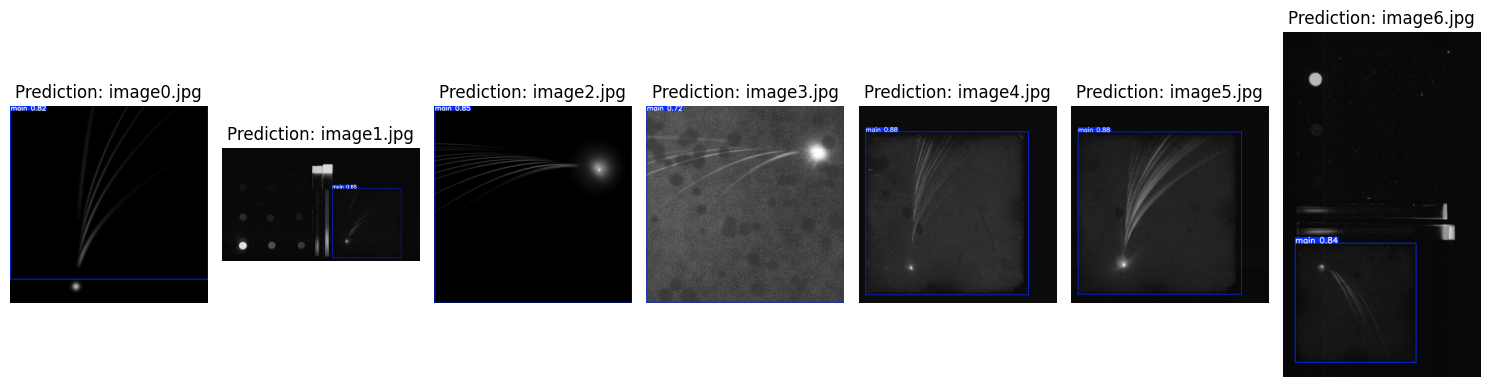

<Figure size 640x480 with 0 Axes>

In [7]:
%matplotlib inline
# Cell 3: Visualize the predictions inline
fig, axes = plt.subplots(1, len(results), figsize=(15, 5))

for i, result in enumerate(results):
    # result.plot() generates a BGR numpy array with the bounding boxes and labels drawn
    annotated_img_bgr = result.plot()
    
    # Convert BGR (OpenCV format) to RGB (Matplotlib format)
    annotated_img_rgb = cv2.cvtColor(annotated_img_bgr, cv2.COLOR_BGR2RGB)
    
    # Handle single image vs multiple image subplot indexing
    ax = axes[i] if len(results) > 1 else axes
    
    ax.imshow(annotated_img_rgb)
    ax.axis('off')
    ax.set_title(f"Prediction: {result.path.split('/')[-1]}")

plt.tight_layout()
plt.show()
plt.savefig('test.png')